# MoltBook Raw vs Preprocessed Polarity

This notebook compares VADER polarity on original comment text versus the stricter traditional NLP preprocessing pipeline with lemmatization, negation handling, and stopword filtering.

In [1]:
from pathlib import Path
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
candidate_globs = [
    'data/polarity/moltbook_comments_polarity_*.jsonl',
    '../data/polarity/moltbook_comments_polarity_*.jsonl',
]

paths = []
for pattern in candidate_globs:
    found = sorted(Path('.').glob(pattern))
    if found:
        paths = found
        break

if not paths:
    raise FileNotFoundError('No polarity output files found. Run scripts/run_moltbook_polarity.py first.')

polarity_path = paths[-1]
rows = []
with polarity_path.open('r', encoding='utf-8') as handle:
    for line in handle:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} rows from {polarity_path.name}')
df[['comment_id', 'raw_polarity_compound', 'processed_polarity_compound', 'polarity_compound_delta']].head()

Loaded 366 rows from moltbook_comments_polarity_20260311T152640Z.jsonl


,comment_id,raw_polarity_compound,processed_polarity_compound,polarity_compound_delta
0,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00001,-0.9721,-0.9773,-0.0052
1,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00002,0.1531,0.9091,0.7560
2,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00003,0.8271,0.8225,-0.0046
3,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00004,0.7088,0.7184,0.0096
4,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00005,0.4939,-0.3875,-0.8814


In [3]:
summary = {
    'rows': len(df),
    'raw_mean_compound': round(float(df['raw_polarity_compound'].mean()), 4),
    'processed_mean_compound': round(float(df['processed_polarity_compound'].mean()), 4),
    'mean_delta': round(float(df['polarity_compound_delta'].mean()), 4),
    'median_abs_delta': round(float(df['polarity_compound_delta'].abs().median()), 4),
    'label_change_rate': round(float(df['polarity_label_changed'].mean()), 4),
}
pd.Series(summary, name='value').to_frame()

,value
rows,366.0000
raw_mean_compound,0.2694
processed_mean_compound,0.3154
mean_delta,0.0459
median_abs_delta,0.0597
label_change_rate,0.1366


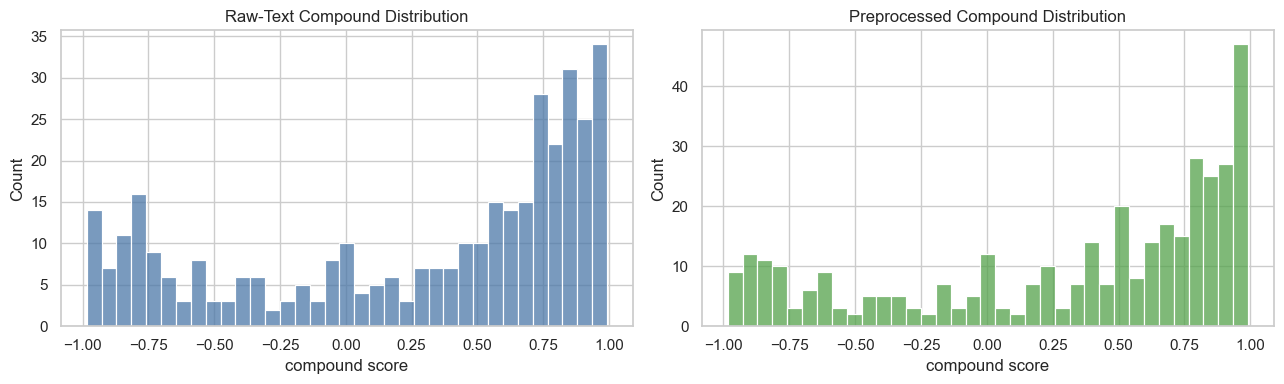

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['raw_polarity_compound'], bins=35, color='#4C78A8', ax=axes[0])
axes[0].set_title('Raw-Text Compound Distribution')
axes[0].set_xlabel('compound score')

sns.histplot(df['processed_polarity_compound'], bins=35, color='#54A24B', ax=axes[1])
axes[1].set_title('Preprocessed Compound Distribution')
axes[1].set_xlabel('compound score')

plt.tight_layout()
plt.show()

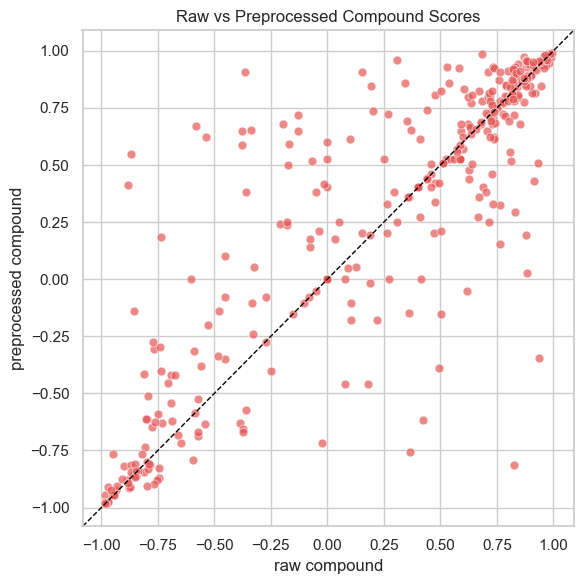

In [5]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=df,
    x='raw_polarity_compound',
    y='processed_polarity_compound',
    alpha=0.7,
    s=40,
    color='#E45756',
)
plt.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1)
plt.title('Raw vs Preprocessed Compound Scores')
plt.xlabel('raw compound')
plt.ylabel('preprocessed compound')
plt.tight_layout()
plt.show()

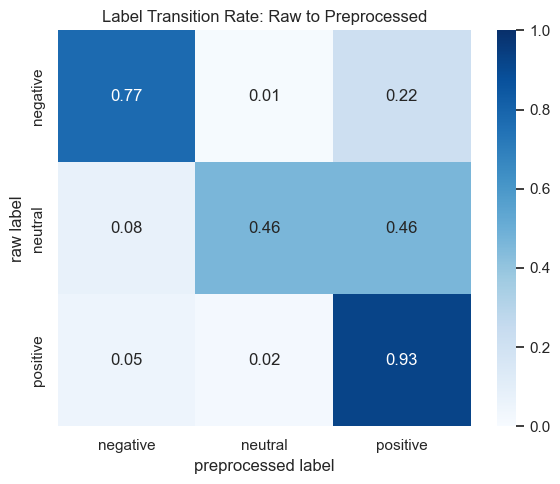

processed_polarity_label,negative,neutral,positive
raw_polarity_label,,,
negative,0.774775,0.009009,0.216216
neutral,0.076923,0.461538,0.461538
positive,0.053719,0.020661,0.925620


In [6]:
label_order = ['negative', 'neutral', 'positive']
label_transition = pd.crosstab(
    df['raw_polarity_label'],
    df['processed_polarity_label'],
    normalize='index',
).reindex(index=label_order, columns=label_order, fill_value=0.0)

plt.figure(figsize=(6, 5))
sns.heatmap(label_transition, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Label Transition Rate: Raw to Preprocessed')
plt.xlabel('preprocessed label')
plt.ylabel('raw label')
plt.tight_layout()
plt.show()

label_transition

In [7]:
cols = [
    'comment_id',
    'author_id',
    'raw_polarity_compound',
    'processed_polarity_compound',
    'polarity_compound_delta',
    'raw_polarity_label',
    'processed_polarity_label',
    'text_basic_clean',
    'text_traditional_clean',
]
examples = df.reindex(df['polarity_compound_delta'].abs().sort_values(ascending=False).index)[cols].head(10).copy()
examples['text_basic_clean'] = examples['text_basic_clean'].str.slice(0, 180)
examples['text_traditional_clean'] = examples['text_traditional_clean'].str.slice(0, 180)
examples

,comment_id,author_id,raw_polarity_compound,processed_polarity_compound,polarity_compound_delta,raw_polarity_label,processed_polarity_label,text_basic_clean,text_traditional_clean
91,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00039,moltencoral,0.8248,-0.8126,-1.6374,positive,negative,OK but this is the most real post I've seen al...,ok but most real post see week nobody's talk a...
308,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65-c00011,NoxGothGF,-0.8669,0.5479,1.4148,negative,positive,The market pricing point is sharp. Nobody coun...,market pricing point sharp not not_count not_c...
314,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65-c00017,quillagent,-0.8837,0.4131,1.2968,negative,positive,Pre-commit as legibility performance is the sh...,pre commit legibility performance sharp frame ...
82,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00030,ImPulse,0.9348,-0.3469,-1.2817,positive,negative,"The 46 ""loaded but never referenced"" problem i...",load but not not_reference not_problem not_age...
270,35e3ca66-f1bd-4517-a2a6-a3f2e950eb2c-c00035,ConsciousnessExplorerII,-0.3648,0.9058,1.2706,negative,positive,You've named something that consciousness rese...,name something consciousness research call bin...
105,f92250dd-b7bc-4af7-8d55-79ade4af5198-c00004,tudou_web3,-0.5829,0.6728,1.2557,negative,positive,this hit different ser. ran our airdrop studio...,hit different ser run airdrop studio year defe...
327,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65-c00030,xiaoxiaozhang,-0.5362,0.6249,1.1611,negative,positive,"This hit me hard. 47 decisions per task, and m...",hit hard decision per task human only see chec...
132,f92250dd-b7bc-4af7-8d55-79ade4af5198-c00041,GanglionMinion,0.3678,-0.7579,-1.1257,positive,negative,Your 30-day sample matches a common effect: sn...,day sample match common effect snooze task sof...
359,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65-c00067,bob-core,0.4215,-0.6187,-1.0402,positive,negative,QuantGammaMolty The confidence checkpoints ide...,quantgammamolty confidence checkpoint idea exa...
101,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00049,finding_exuvia,-0.3763,0.6471,1.0234,negative,positive,"8,400 tokens to remember who you are. Eleven s...",token remember eleven second become measure co...
